# TRIDENT-201 Multivariable Survival Analysis

This notebook evaluates whether the estimated TRIDENT + SOC effect on progression-free survival (PFS) persists after adjustment for clinically relevant baseline prognostic variables and examines the robustness of the treatment estimate to proportional-hazards assumption concerns.

In [1]:
# Standard Python and data-analysis tools
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Survival-modeling tools
import lifelines
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test

# Confirm the active Python environment and key package versions
print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("pandas version:", pd.__version__)
print("lifelines version:", lifelines.__version__)

Python executable: /Users/goncabulbul/miniconda3/envs/trident/bin/python
Python version: 3.11.15
pandas version: 2.3.3
lifelines version: 0.30.3


In [2]:
# The notebook is inside the project's notebooks directory,
# so its parent directory is the project root
PROJECT_ROOT = Path("..").resolve()

# Point to the original clinical dataset
clinical_file_path = (
    PROJECT_ROOT / "data" / "raw" / "clinical.csv"
)

# Confirm that the expected file can be found
print("Project root:", PROJECT_ROOT)
print("Clinical data path:", clinical_file_path)
print("Clinical file exists:", clinical_file_path.exists())

Project root: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis
Clinical data path: /Users/goncabulbul/Documents/GitHub/TRIDENT-201-translational-analysis/data/raw/clinical.csv
Clinical file exists: True


In [3]:
# Load the original clinical data
# We will treat this object as read-only
clinical_original = pd.read_csv(clinical_file_path)

# Create an independent copy for this notebook's analysis
multivariable_working = clinical_original.copy()

# Confirm the dataset dimensions and available variables
print("Original clinical data shape:", clinical_original.shape)
print("Working-copy shape:", multivariable_working.shape)

print("\nAvailable clinical columns:")
print(multivariable_working.columns.tolist())

Original clinical data shape: (251, 15)
Working-copy shape: (251, 15)

Available clinical columns:
['patient_id', 'treatment_arm', 'age', 'sex', 'disease_stage', 'ecog_status', 'smoking_status', 'histology', 'best_overall_response', 'pfs_days', 'pfs_event', 'os_days', 'os_event', 'study_site', 'enrollment_date']


In [4]:
# Apply the previously validated patient-level duplicate rule:
# retain the first record for each patient ID
multivariable_patient_data = (
    multivariable_working
    .drop_duplicates(subset="patient_id", keep="first")
    .copy()
)

# Confirm the duplicate handling
print("Rows before duplicate removal:", len(multivariable_working))
print("Rows after duplicate removal:", len(multivariable_patient_data))
print(
    "Unique patients after duplicate removal:",
    multivariable_patient_data["patient_id"].nunique()
)
print(
    "TRI-075 records retained:",
    (multivariable_patient_data["patient_id"] == "TRI-075").sum()
)

Rows before duplicate removal: 251
Rows after duplicate removal: 250
Unique patients after duplicate removal: 250
TRI-075 records retained: 1


In [5]:
# Keep patients with valid PFS duration and event information
pfs_multivariable_data = multivariable_patient_data.loc[
    multivariable_patient_data["pfs_days"].notna()
    & multivariable_patient_data["pfs_event"].isin([0, 1])
    & (multivariable_patient_data["pfs_days"] >= 0)
].copy()

# Identify patients excluded only from the PFS population
print("Patient-level population:", len(multivariable_patient_data))
print("Valid PFS population:", len(pfs_multivariable_data))

print("\nPatients excluded from PFS analysis:")
print(
    multivariable_patient_data.loc[
        ~multivariable_patient_data["patient_id"].isin(
            pfs_multivariable_data["patient_id"]
        ),
        ["patient_id", "pfs_days", "pfs_event"]
    ]
)

Patient-level population: 250
Valid PFS population: 249

Patients excluded from PFS analysis:
    patient_id  pfs_days  pfs_event
137    TRI-138       -14          1


In [6]:
# Define clinically plausible baseline adjustment variables
candidate_baseline_columns = [
    "treatment_arm",
    "age",
    "sex",
    "disease_stage",
    "ecog_status",
    "smoking_status",
    "histology"
]

# Summarize completeness and number of observed values
candidate_baseline_summary = pd.DataFrame({
    "data_type": (
        pfs_multivariable_data[candidate_baseline_columns]
        .dtypes.astype(str)
    ),
    "missing_n": (
        pfs_multivariable_data[candidate_baseline_columns]
        .isna().sum()
    ),
    "missing_percent": (
        pfs_multivariable_data[candidate_baseline_columns]
        .isna().mean().mul(100).round(1)
    ),
    "unique_values": (
        pfs_multivariable_data[candidate_baseline_columns]
        .nunique(dropna=True)
    )
})

display(candidate_baseline_summary)

,data_type,missing_n,missing_percent,unique_values
treatment_arm,object,0,0.0,3
age,int64,0,0.0,48
sex,object,0,0.0,3
disease_stage,object,0,0.0,2
ecog_status,int64,0,0.0,4
smoking_status,object,0,0.0,3
histology,object,0,0.0,3


In [7]:
# Inspect the exact labels and frequencies of categorical covariates
categorical_candidate_columns = [
    "treatment_arm",
    "sex",
    "disease_stage",
    "smoking_status",
    "histology"
]

for column_name in categorical_candidate_columns:
    print(f"\n{column_name}:")
    print(pfs_multivariable_data[column_name].value_counts(dropna=False))

# Display records with implausible age or invalid ECOG values
potential_covariate_qc_rows = pfs_multivariable_data.loc[
    (pfs_multivariable_data["age"] > 100)
    | (~pfs_multivariable_data["ecog_status"].isin([0, 1, 2, 3, 4])),
    ["patient_id", "age", "ecog_status"]
]

print("\nPotential age or ECOG QC issues:")
display(potential_covariate_qc_rows)


treatment_arm:
treatment_arm
TRIDENT + SOC    124
SOC              124
Trident + SOC      1
Name: count, dtype: int64

sex:
sex
Male      140
Female    108
F           1
Name: count, dtype: int64

disease_stage:
disease_stage
IV     176
III     73
Name: count, dtype: int64

smoking_status:
smoking_status
Former     141
Never       63
Current     45
Name: count, dtype: int64

histology:
histology
Adenocarcinoma    169
Squamous           60
Other              20
Name: count, dtype: int64

Potential age or ECOG QC issues:


,patient_id,age,ecog_status
16,TRI-017,152,1
88,TRI-089,73,7


In [8]:
# Create a separate copy for covariate-specific QC
pfs_covariate_qc_data = pfs_multivariable_data.copy()

# Standardize obvious categorical-label inconsistencies
pfs_covariate_qc_data["treatment_arm"] = (
    pfs_covariate_qc_data["treatment_arm"]
    .replace({"Trident + SOC": "TRIDENT + SOC"})
)

pfs_covariate_qc_data["sex"] = (
    pfs_covariate_qc_data["sex"]
    .replace({"F": "Female"})
)

# Mark invalid numeric covariates as missing;
# do not guess their correct clinical values
pfs_covariate_qc_data.loc[
    pfs_covariate_qc_data["age"] > 100,
    "age"
] = np.nan

pfs_covariate_qc_data.loc[
    ~pfs_covariate_qc_data["ecog_status"].isin([0, 1, 2, 3, 4]),
    "ecog_status"
] = np.nan

# Verify the corrections
print("Treatment-arm counts:")
print(pfs_covariate_qc_data["treatment_arm"].value_counts(dropna=False))

print("\nSex counts:")
print(pfs_covariate_qc_data["sex"].value_counts(dropna=False))

print("\nMissing age values:", pfs_covariate_qc_data["age"].isna().sum())
print("Missing ECOG values:", pfs_covariate_qc_data["ecog_status"].isna().sum())

Treatment-arm counts:
treatment_arm
TRIDENT + SOC    125
SOC              124
Name: count, dtype: int64

Sex counts:
sex
Male      140
Female    109
Name: count, dtype: int64

Missing age values: 1
Missing ECOG values: 1


In [9]:
# Variables required for the proposed adjusted PFS model
complete_case_columns = [
    "pfs_days",
    "pfs_event",
    "treatment_arm",
    "age",
    "sex",
    "disease_stage",
    "ecog_status",
    "smoking_status",
    "histology"
]

# Retain patients with complete information for all proposed variables
pfs_complete_case_data = (
    pfs_covariate_qc_data[complete_case_columns]
    .dropna()
    .copy()
)

# Summarize the available modeling population
print("Valid PFS population:", len(pfs_covariate_qc_data))
print("Complete-case population:", len(pfs_complete_case_data))
print("Patients excluded for missing covariates:",
      len(pfs_covariate_qc_data) - len(pfs_complete_case_data))
print("PFS events in complete cases:",
      int(pfs_complete_case_data["pfs_event"].sum()))
print("Censored PFS observations:",
      int((pfs_complete_case_data["pfs_event"] == 0).sum()))

Valid PFS population: 249
Complete-case population: 247
Patients excluded for missing covariates: 2
PFS events in complete cases: 179
Censored PFS observations: 68


In [10]:
# Categorical predictors proposed for the adjusted PFS model
model_categorical_columns = [
    "treatment_arm",
    "sex",
    "disease_stage",
    "ecog_status",
    "smoking_status",
    "histology"
]

# Display category counts in the actual modeling population
for column_name in model_categorical_columns:
    print(f"\n{column_name}:")
    print(
        pfs_complete_case_data[column_name]
        .value_counts(dropna=False)
        .sort_index()
    )


treatment_arm:
treatment_arm
SOC              124
TRIDENT + SOC    123
Name: count, dtype: int64

sex:
sex
Female    108
Male      139
Name: count, dtype: int64

disease_stage:
disease_stage
III     72
IV     175
Name: count, dtype: int64

ecog_status:
ecog_status
0.0     59
1.0    136
2.0     52
Name: count, dtype: int64

smoking_status:
smoking_status
Current     45
Former     140
Never       62
Name: count, dtype: int64

histology:
histology
Adenocarcinoma    168
Other              20
Squamous           59
Name: count, dtype: int64


In [11]:
# Create a modeling copy of the complete-case data
pfs_model_source = pfs_complete_case_data.copy()

# Express age in clinically interpretable 10-year units
pfs_model_source["age_per_10_years"] = (
    pfs_model_source["age"] / 10
)

# Set the first category in each list as the reference group
reference_categories = {
    "treatment_arm": ["SOC", "TRIDENT + SOC"],
    "sex": ["Female", "Male"],
    "disease_stage": ["III", "IV"],
    "ecog_status": [0.0, 1.0, 2.0],
    "smoking_status": ["Never", "Former", "Current"],
    "histology": ["Adenocarcinoma", "Squamous", "Other"]
}

for variable_name, categories in reference_categories.items():
    pfs_model_source[variable_name] = pd.Categorical(
        pfs_model_source[variable_name],
        categories=categories
    )

# Convert categorical predictors into 0/1 indicator columns
pfs_encoded_data = pd.get_dummies(
    pfs_model_source.drop(columns="age"),
    columns=list(reference_categories.keys()),
    drop_first=True,
    dtype=int
)

print("Encoded modeling shape:", pfs_encoded_data.shape)
print("\nEncoded columns:")
for column_name in pfs_encoded_data.columns:
    print("-", column_name)

Encoded modeling shape: (247, 12)

Encoded columns:
- pfs_days
- pfs_event
- age_per_10_years
- treatment_arm_TRIDENT + SOC
- sex_Male
- disease_stage_IV
- ecog_status_1.0
- ecog_status_2.0
- smoking_status_Former
- smoking_status_Current
- histology_Squamous
- histology_Other


In [12]:
# Create and fit the multivariable PFS Cox model
pfs_multivariable_cox = CoxPHFitter()

pfs_multivariable_cox.fit(
    pfs_encoded_data,
    duration_col="pfs_days",
    event_col="pfs_event"
)

# Create a concise, interpretable results table
pfs_multivariable_results = (
    pfs_multivariable_cox.summary[
        [
            "coef",
            "exp(coef)",
            "exp(coef) lower 95%",
            "exp(coef) upper 95%",
            "p"
        ]
    ]
    .rename(columns={
        "exp(coef)": "adjusted_hr",
        "exp(coef) lower 95%": "ci_lower",
        "exp(coef) upper 95%": "ci_upper",
        "p": "p_value"
    })
)

display(pfs_multivariable_results.round(3))

,coef,adjusted_hr,ci_lower,ci_upper,p_value
covariate,,,,,
age_per_10_years,-0.013,0.987,0.840,1.161,0.878
treatment_arm_TRIDENT + SOC,-0.797,0.451,0.329,0.617,0.000
sex_Male,-0.056,0.945,0.691,1.293,0.724
disease_stage_IV,0.279,1.321,0.940,1.857,0.109
ecog_status_1.0,-0.203,0.816,0.567,1.175,0.274
ecog_status_2.0,0.123,1.131,0.727,1.761,0.585
smoking_status_Former,-0.379,0.685,0.478,0.981,0.039
smoking_status_Current,-0.776,0.460,0.283,0.750,0.002
histology_Squamous,0.238,1.269,0.888,1.813,0.192


In [13]:
# Fit the unadjusted treatment model in the same 247 patients
pfs_complete_case_unadjusted_cox = CoxPHFitter()

pfs_complete_case_unadjusted_cox.fit(
    pfs_encoded_data[
        [
            "pfs_days",
            "pfs_event",
            "treatment_arm_TRIDENT + SOC"
        ]
    ],
    duration_col="pfs_days",
    event_col="pfs_event"
)

# Compare treatment estimates using an identical patient population
pfs_treatment_hr_comparison = pd.DataFrame({
    "model": [
        "Treatment only, complete cases",
        "Adjusted baseline model"
    ],
    "hazard_ratio": [
        pfs_complete_case_unadjusted_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef)"
        ],
        pfs_multivariable_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef)"
        ]
    ],
    "ci_lower": [
        pfs_complete_case_unadjusted_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef) lower 95%"
        ],
        pfs_multivariable_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef) lower 95%"
        ]
    ],
    "ci_upper": [
        pfs_complete_case_unadjusted_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef) upper 95%"
        ],
        pfs_multivariable_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "exp(coef) upper 95%"
        ]
    ],
    "p_value": [
        pfs_complete_case_unadjusted_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "p"
        ],
        pfs_multivariable_cox.summary.loc[
            "treatment_arm_TRIDENT + SOC", "p"
        ]
    ]
})

display(pfs_treatment_hr_comparison)

,model,hazard_ratio,ci_lower,ci_upper,p_value
0,"Treatment only, complete cases",0.520357,0.385746,0.701943,1.892421e-05
1,Adjusted baseline model,0.450832,0.329493,0.616856,6.358784e-07


In [14]:
# Test proportional hazards using two time transformations
pfs_multivariable_ph_km = proportional_hazard_test(
    pfs_multivariable_cox,
    pfs_encoded_data,
    time_transform="km"
)

pfs_multivariable_ph_rank = proportional_hazard_test(
    pfs_multivariable_cox,
    pfs_encoded_data,
    time_transform="rank"
)

# Combine both diagnostic results for easier comparison
pfs_multivariable_ph_summary = (
    pfs_multivariable_ph_km.summary[
        ["test_statistic", "p"]
    ]
    .rename(columns={
        "test_statistic": "km_statistic",
        "p": "km_p_value"
    })
    .join(
        pfs_multivariable_ph_rank.summary[
            ["test_statistic", "p"]
        ].rename(columns={
            "test_statistic": "rank_statistic",
            "p": "rank_p_value"
        })
    )
    .sort_values("rank_p_value")
)

display(pfs_multivariable_ph_summary.round(4))

,km_statistic,km_p_value,rank_statistic,rank_p_value
age_per_10_years,3.9909,0.0457,3.9497,0.0469
disease_stage_IV,3.8214,0.0506,3.9126,0.0479
treatment_arm_TRIDENT + SOC,1.6397,0.2004,1.9914,0.1582
sex_Male,1.4013,0.2365,1.8231,0.1769
histology_Squamous,1.0361,0.3087,1.2732,0.2592
histology_Other,1.1179,0.2904,1.2417,0.2651
ecog_status_2.0,0.9069,0.3409,0.7281,0.3935
ecog_status_1.0,0.4688,0.4935,0.3217,0.5706
smoking_status_Former,0.2688,0.6041,0.3139,0.5753
smoking_status_Current,0.2280,0.6330,0.2599,0.6102



   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'age_per_10_years' failed the non-proportional test: p-value is 0.0457.

   Advice 1: the functional form of the variable 'age_per_10_years' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'age_per_10_years' using pd.cut, and then specify it in
`strata=['age_per_10_years', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


2. Variable 'disease_stage_IV' failed the non-proportional test: p-value is 0.0479.

   Advice: with so few unique values (only 2), you can include `strata=['disease_stage_IV', ...]` in
the call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelin

[[<Axes: xlabel='rank-transformed time\n(p=0.0469)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0457)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0479)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0506)'>]]

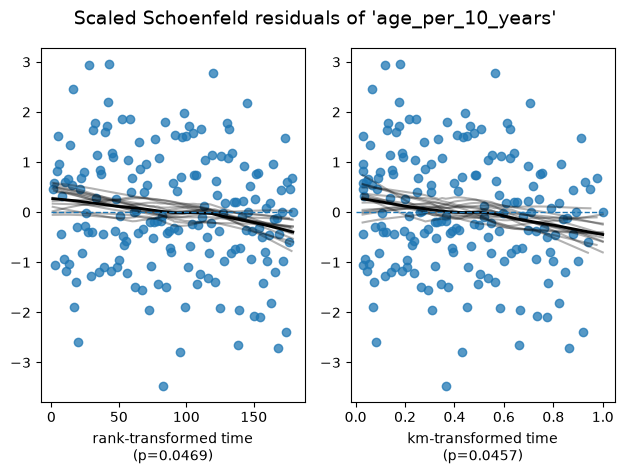

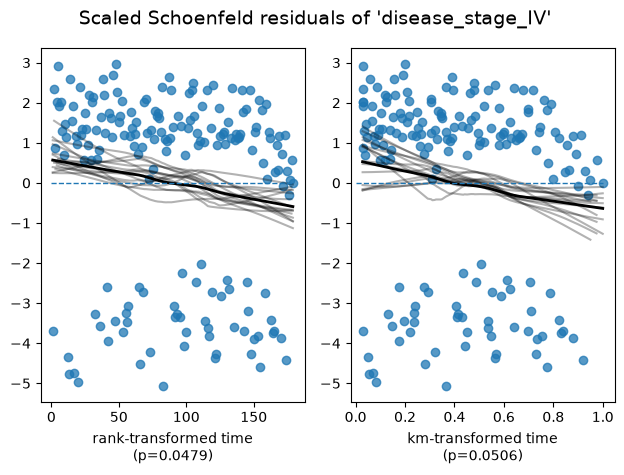

In [15]:
# Examine only the two covariates with borderline PH-test results
pfs_multivariable_cox.check_assumptions(
    pfs_encoded_data,
    p_value_threshold=0.05,
    show_plots=True,
    columns=[
        "age_per_10_years",
        "disease_stage_IV"
    ]
)

In [16]:
### Objective
# Fit a stage-stratified Cox model as a sensitivity analysis.
# This allows Stage III and Stage IV to have different baseline hazards,
# while preserving the treatment effect estimate.

# Create a copy of the complete-case modeling data
pfs_stage_stratified_data = pfs_model_source.copy()

# Remove the original age column because age_per_10_years is already available
pfs_stage_stratified_data = pfs_stage_stratified_data.drop(columns="age")

# Convert all categorical covariates EXCEPT disease stage into indicator variables
pfs_stage_stratified_encoded = pd.get_dummies(
    pfs_stage_stratified_data,
    columns=[
        "treatment_arm",
        "sex",
        "ecog_status",
        "smoking_status",
        "histology"
    ],
    drop_first=True,
    dtype=int
)

# Create and fit the Cox model, stratifying by disease stage
pfs_stage_stratified_cox = CoxPHFitter()

pfs_stage_stratified_cox.fit(
    pfs_stage_stratified_encoded,
    duration_col="pfs_days",
    event_col="pfs_event",
    strata=["disease_stage"]
)

pfs_stage_stratified_cox.summary[
    [
        "exp(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p"
    ]
].round(3)

/Users/goncabulbul/miniconda3/envs/trident/lib/python3.11/site-packages/lifelines/fitters/__init__.py:1284: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, df_ in df.groupby(strata):
/Users/goncabulbul/miniconda3/envs/trident/lib/python3.11/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for stratum, stratified_X in X.groupby(self.strata):
/Users/goncabulbul/miniconda3/envs/trident/lib/python3.11/site-packages/lifelines/fitters/coxph_fitter.py:1868: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future 

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
age_per_10_years,1.012,0.858,1.194,0.885
treatment_arm_TRIDENT + SOC,0.453,0.331,0.620,0.000
sex_Male,0.937,0.683,1.284,0.684
ecog_status_1.0,0.816,0.567,1.174,0.274
ecog_status_2.0,1.047,0.665,1.650,0.842
smoking_status_Former,0.694,0.484,0.995,0.047
smoking_status_Current,0.459,0.279,0.752,0.002
histology_Squamous,1.231,0.857,1.769,0.260
histology_Other,0.680,0.358,1.290,0.238


In [17]:
### Objective
# Fit a Cox model with a flexible nonlinear age effect
# using a B-spline instead of assuming age has a strictly linear effect.

pfs_age_spline_cox = CoxPHFitter()

pfs_age_spline_cox.fit(
    pfs_encoded_data,
    duration_col="pfs_days",
    event_col="pfs_event",
    formula=(
        "bs(age_per_10_years, df=4, degree=3, include_intercept=False) + "
        "Q('treatment_arm_TRIDENT + SOC') + "
        "sex_Male + "
        "disease_stage_IV + "
        "Q('ecog_status_1.0') + "
        "Q('ecog_status_2.0') + "
        "smoking_status_Former + "
        "smoking_status_Current + "
        "histology_Squamous + "
        "histology_Other"
    )
)

pfs_age_spline_cox.summary[
    [
        "coef",
        "exp(coef)",
        "exp(coef) lower 95%",
        "exp(coef) upper 95%",
        "p"
    ]
].round(3)

,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
"bs(age_per_10_years, df=4, degree=3, include_intercept=False)[1]",1.105,3.021,0.198,46.129,0.427
"bs(age_per_10_years, df=4, degree=3, include_intercept=False)[2]",-0.666,0.514,0.098,2.684,0.430
"bs(age_per_10_years, df=4, degree=3, include_intercept=False)[3]",0.743,2.102,0.209,21.176,0.529
"bs(age_per_10_years, df=4, degree=3, include_intercept=False)[4]",0.297,1.346,0.215,8.435,0.751
Q('treatment_arm_TRIDENT + SOC'),-0.805,0.447,0.326,0.613,0.000
sex_Male,-0.102,0.903,0.654,1.247,0.536
disease_stage_IV,0.366,1.443,1.003,2.076,0.048
Q('ecog_status_1.0'),-0.212,0.809,0.562,1.165,0.254
Q('ecog_status_2.0'),0.146,1.158,0.742,1.805,0.519


In [18]:
### Objective
# Split each patient's PFS follow-up into 30-day intervals
# so we can later model whether the effect of age changes over time.

from lifelines.utils import to_episodic_format

# Start from the encoded complete-case dataset used in our Cox model.
pfs_episodic_source = pfs_encoded_data.copy().reset_index(drop=True)

# Give every patient a unique ID.
pfs_episodic_source["patient_number"] = range(len(pfs_episodic_source))

# Split each patient's follow-up into 30-day intervals.
pfs_episodic_data = to_episodic_format(
    pfs_episodic_source,
    duration_col="pfs_days",
    event_col="pfs_event",
    id_col="patient_number",
    time_gaps=30
)

# Look at the first 15 rows.
pfs_episodic_data[
    ["patient_number", "start", "stop", "pfs_event", "age_per_10_years"]
].head(15)

,patient_number,start,stop,pfs_event,age_per_10_years
0,0,0.0,30.0,0,7.1
1,0,30.0,60.0,0,7.1
2,0,60.0,90.0,0,7.1
3,0,90.0,120.0,0,7.1
4,0,120.0,150.0,0,7.1
5,0,150.0,180.0,0,7.1
6,0,180.0,210.0,0,7.1
7,0,210.0,240.0,0,7.1
8,0,240.0,270.0,0,7.1
9,0,270.0,300.0,0,7.1


In [19]:
### Objective
# Create an age-by-time interaction so the age effect
# is allowed to change as follow-up time increases.

# Use log(time + 1) so very large follow-up times
# do not dominate the interaction.
pfs_episodic_data["log_time"] = np.log(
    pfs_episodic_data["stop"] + 1
)

# Interaction between age and follow-up time.
pfs_episodic_data["age_x_log_time"] = (
    pfs_episodic_data["age_per_10_years"]
    * pfs_episodic_data["log_time"]
)

# Inspect the new variables.
pfs_episodic_data[
    [
        "patient_number",
        "start",
        "stop",
        "age_per_10_years",
        "log_time",
        "age_x_log_time"
    ]
].head(12)

,patient_number,start,stop,age_per_10_years,log_time,age_x_log_time
0,0,0.0,30.0,7.1,3.433987,24.381309
1,0,30.0,60.0,7.1,4.110874,29.187204
2,0,60.0,90.0,7.1,4.510860,32.027102
3,0,90.0,120.0,7.1,4.795791,34.050113
4,0,120.0,150.0,7.1,5.017280,35.622687
5,0,150.0,180.0,7.1,5.198497,36.909329
6,0,180.0,210.0,7.1,5.351858,37.998193
7,0,210.0,240.0,7.1,5.484797,38.942058
8,0,240.0,270.0,7.1,5.602119,39.775044
9,0,270.0,300.0,7.1,5.707110,40.520483


In [20]:
### Objective
# Fit a simpler time-varying Cox model focused on our main question:
# does the association between age and PFS change over time?

from lifelines import CoxTimeVaryingFitter

timevarying_test_columns = [
    "patient_number",
    "start",
    "stop",
    "pfs_event",
    "age_per_10_years",
    "age_x_log_time",
    "treatment_arm_TRIDENT + SOC"
]

pfs_timevarying_test_data = (
    pfs_episodic_data[timevarying_test_columns]
    .copy()
)

# Fit the simplified model.
pfs_timevarying_test_cox = CoxTimeVaryingFitter()

pfs_timevarying_test_cox.fit(
    pfs_timevarying_test_data,
    id_col="patient_number",
    start_col="start",
    stop_col="stop",
    event_col="pfs_event"
)

# Display the results.
pfs_timevarying_test_cox.summary[
    ["coef", "exp(coef)", "exp(coef) lower 95%",
     "exp(coef) upper 95%", "p"]
].round(3)

,coef,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,,
age_per_10_years,10.434,34011.664,5001.516,231288.512,0.0
age_x_log_time,-1.897,0.150,0.106,0.212,0.0
treatment_arm_TRIDENT + SOC,-0.610,0.543,0.400,0.738,0.0


In [21]:
### Objective
# Calculate the estimated hazard ratio for a 10-year increase in age
# at several follow-up times.

age_coef = pfs_timevarying_test_cox.params_["age_per_10_years"]
age_time_coef = pfs_timevarying_test_cox.params_["age_x_log_time"]

age_effect_by_time = pd.DataFrame({
    "time_days": [30, 90, 180, 365]
})

age_effect_by_time["age_HR_per_10_years"] = np.exp(
    age_coef
    + age_time_coef * np.log(age_effect_by_time["time_days"] + 1)
)

age_effect_by_time.round(3)

,time_days,age_HR_per_10_years
0,30,50.349
1,90,6.526
2,180,1.770
3,365,0.465


In [22]:
### Objective
# Summarize the treatment estimate and the time-dependent age effect
# from the simplified time-varying Cox sensitivity analysis.

timevarying_summary = pd.DataFrame({
    "result": [
        "Treatment HR",
        "Treatment 95% CI lower",
        "Treatment 95% CI upper",
        "Age x log(time) coefficient",
        "Age x log(time) p-value"
    ],
    "value": [
        pfs_timevarying_test_cox.hazard_ratios_["treatment_arm_TRIDENT + SOC"],
        np.exp(
            pfs_timevarying_test_cox.confidence_intervals_.loc[
                "treatment_arm_TRIDENT + SOC", "95% lower-bound"
            ]
        ),
        np.exp(
            pfs_timevarying_test_cox.confidence_intervals_.loc[
                "treatment_arm_TRIDENT + SOC", "95% upper-bound"
            ]
        ),
        pfs_timevarying_test_cox.params_["age_x_log_time"],
        pfs_timevarying_test_cox.summary.loc["age_x_log_time", "p"]
    ]
})

timevarying_summary.round(4)

,result,value
0,Treatment HR,0.5431
1,Treatment 95% CI lower,0.3999
2,Treatment 95% CI upper,0.7377
3,Age x log(time) coefficient,-1.8974
4,Age x log(time) p-value,0.0000


### Time-varying age sensitivity analysis

The proportional-hazards diagnostics suggested a possible time-dependent association between age and PFS. To explore whether this affected the primary treatment conclusion, follow-up was divided into 30-day intervals and a simplified time-varying Cox model was fitted with an age-by-log(time) interaction.

The age-by-log(time) interaction was negative (coefficient = -1.897, p < 0.001), indicating that the estimated association between age and PFS hazard changed over follow-up. Because the resulting age-specific hazard ratios were extreme at early time points, this flexible model was treated as a sensitivity analysis rather than evidence of a clinically meaningful age effect.

Importantly, the TRIDENT + SOC treatment effect remained favorable (HR = 0.543, 95% CI 0.400–0.738), supporting the robustness of the primary conclusion that TRIDENT + SOC was associated with lower PFS hazard compared with SOC.

### Conclusions

The multivariable Cox analysis showed that TRIDENT + SOC was associated with a substantially lower PFS hazard compared with SOC after adjustment for baseline clinical covariates (adjusted HR ≈ 0.45).

Proportional-hazards diagnostics suggested possible non-proportionality for age and disease stage. However, the treatment effect remained consistent across sensitivity analyses, including stage-stratified Cox modeling, flexible modeling of age, and a simplified time-varying Cox analysis. These results support the robustness of the treatment-PFS association.

Some covariate estimates, particularly smoking-status associations and the extreme early age effects in the time-varying model, were counterintuitive and should not be overinterpreted. Because this is a synthetic portfolio dataset, these findings are best viewed as demonstrations of model diagnostics, sensitivity analysis, and translational interpretation rather than as clinically generalizable conclusions.